**Prepared By:** Mirza Md Tasnim Mukarram
*Informatics, Department of Computer Science, University of Iowa*
*Geographic Information Science and Cartography, School of Earth, Environment and Sustainability, University of Iowa*

# Molniya Orbit Geometry and the Sun-Earth L1 Point

*A compact orbital-mechanics workshop for satellite remote sensing.*

Highly elliptical orbits (HEOs) such as the **Molniya orbit** trade a circular
ground track for something more useful at high latitudes: a satellite that
lingers over one hemisphere for most of its period. That long *apogee dwell* is
why Molniya-class orbits have carried communications and high-latitude
observing payloads for decades, and it is a direct consequence of orbit
geometry and Kepler's laws.

This notebook works through that geometry end to end for a representative
Molniya orbit (`e = 0.722`, `T = 12 h`), and then steps outside Earth orbit to
locate the **Sun-Earth L1 Lagrange point**, the vantage that hosts
space-weather and Earth-observing missions such as SOHO and DSCOVR.

Everything is derived from first principles, kept in SI units internally, and
reported in familiar units. The code is written as small reusable functions so
the same routines apply to any two-body orbit, not just this one.

**Contents**

1. Orbit geometry from Kepler's third law (semi-axes, perigee, apogee)
2. Orbital speed: transverse component vs. total speed
3. Time of flight via Kepler's equation
4. Orbit visualization with hourly satellite positions
5. The Sun-Earth L1 point: first-order estimate and numerical refinement

---

In [1]:
# ---------------------------------------------------------------
# Setup: imports, physical constants, and figure style
# ---------------------------------------------------------------
%matplotlib inline
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.optimize import brentq

# --- Physical constants (SI), defined once and reused throughout -------
G     = 6.67430e-11        # gravitational constant   [m^3 kg^-1 s^-2]
M_E   = 5.9722e24          # mass of Earth            [kg]
R_E   = 6.371e6            # mean radius of Earth     [m]
M_S   = 1.98892e30         # mass of Sun              [kg]
R_S   = 6.957e8            # mean radius of Sun       [m]
AU    = 1.495978707e11     # astronomical unit        [m]
MU_E  = G * M_E            # Earth gravitational parameter [m^3 s^-2]

# --- Molniya orbit parameters ------------------------------------------
E_ORB = 0.722              # eccentricity            [-]
T_ORB = 12 * 3600.0        # orbital period          [s]

# --- Consistent, restrained plotting style -----------------------------
plt.rcParams.update({
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "font.family":      "serif",
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   13,
    "axes.titleweight": "semibold",
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

C_ORBIT = "#1f4e79"   # deep blue  - orbit path / primary curve
C_TOTAL = "#1f4e79"   # deep blue  - total speed
C_TRANS = "#c0504d"   # brick red  - transverse speed
C_MARK  = "#e08e0b"   # amber      - satellite markers
C_EARTH = "#2e6fb0"   # Earth disk

print(f"Earth gravitational parameter  mu_E = {MU_E:.6e} m^3 s^-2")
print(f"Molniya orbit:  e = {E_ORB},  T = {T_ORB/3600:.0f} h")


Earth gravitational parameter  mu_E = 3.986025e+14 m^3 s^-2
Molniya orbit:  e = 0.722,  T = 12 h


## 1. Orbit geometry from Kepler's third law

For a body orbiting Earth, Kepler's third law fixes the semi-major axis from
the period alone:

$$T^2 = \frac{4\pi^2}{\mu_E}\,a^3 \quad\Longrightarrow\quad
a = \left(\frac{\mu_E\,T^2}{4\pi^2}\right)^{1/3}.$$

The semi-minor axis follows from the eccentricity, and the apsidal distances
(measured from Earth's center, which sits at a focus) are set by $a$ and $e$:

$$b = a\sqrt{1-e^2}, \qquad r_\text{peri} = a(1-e), \qquad r_\text{apo} = a(1+e).$$


In [2]:
# ---------------------------------------------------------------
# Geometry helpers (apply to any bound two-body orbit)
# ---------------------------------------------------------------
def semi_major_axis(T, mu=MU_E):
    """Semi-major axis a [m] from period T [s] via Kepler's third law."""
    return (mu * T**2 / (4 * np.pi**2))**(1/3)

def semi_minor_axis(a, e):
    """Semi-minor axis b [m] from a [m] and eccentricity e."""
    return a * np.sqrt(1 - e**2)

# --- Evaluate for the Molniya orbit ------------------------------------
a = semi_major_axis(T_ORB)
b = semi_minor_axis(a, E_ORB)

r_peri = a * (1 - E_ORB)
r_apo  = a * (1 + E_ORB)
h_peri = r_peri - R_E          # altitude above surface
h_apo  = r_apo  - R_E

# --- Report ------------------------------------------------------------
rows = [
    ("Semi-major axis   a",  a,      a/1000),
    ("Semi-minor axis   b",  b,      b/1000),
    ("Perigee radius    r_p", r_peri, r_peri/1000),
    ("Apogee radius     r_a", r_apo,  r_apo/1000),
    ("Perigee altitude",     h_peri, h_peri/1000),
    ("Apogee altitude",      h_apo,  h_apo/1000),
]
print(f"{'quantity':22s}{'value [m]':>16s}{'value [km]':>16s}")
print("-" * 54)
for name, m, km in rows:
    print(f"{name:22s}{m:16.3e}{km:16,.1f}")


quantity                     value [m]      value [km]
------------------------------------------------------
Semi-major axis   a          2.661e+07        26,610.3
Semi-minor axis   b          1.841e+07        18,411.5
Perigee radius    r_p        7.398e+06         7,397.7
Apogee radius     r_a        4.582e+07        45,822.9
Perigee altitude             1.027e+06         1,026.7
Apogee altitude              3.945e+07        39,451.9


These numbers match the real Molniya family closely: a period of half a
sidereal day (so the ground track repeats), a perigee a few hundred to a
thousand kilometres up, and an apogee near 39,000 km altitude over the
high-latitude hemisphere. The large apogee radius is where the *dwell* comes
from, quantified next.

## 2. Orbital speed: transverse component vs. total speed

There are two different "speeds" worth separating, and conflating them is a
common slip.

**Transverse speed** follows from Kepler's second law (equal areas in equal
times). Over a full period the radius vector sweeps the whole ellipse area
$S=\pi a b$, so the areal rate is $S/T$, and the component of velocity
*perpendicular to the radius* is

$$V_\perp(r) = \frac{2S}{rT} = \frac{2\pi a b}{rT}.$$

**Total speed** is what a tracker actually measures, and it comes from the
vis-viva equation:

$$V(r) = \sqrt{\mu_E\!\left(\frac{2}{r}-\frac{1}{a}\right)}.$$

The two agree *exactly* at perigee and apogee, where the motion is purely
transverse (the radial velocity vanishes at the apses), and $V > V_\perp$
everywhere in between. Plotting both makes the distinction concrete.


In [3]:
# ---------------------------------------------------------------
# Speed models as functions of true anomaly nu
# ---------------------------------------------------------------
def radius_of_true_anomaly(nu, a, e):
    """Earth-satellite distance r [m] at true anomaly nu [rad]."""
    return a * (1 - e**2) / (1 + e * np.cos(nu))

def transverse_speed(r, a, b, T):
    """Kepler-second-law transverse speed V_perp = 2 pi a b / (r T)  [m/s]."""
    return 2 * np.pi * a * b / (r * T)

def total_speed(r, a, mu=MU_E):
    """Vis-viva total orbital speed V = sqrt(mu (2/r - 1/a))  [m/s]."""
    return np.sqrt(mu * (2 / r - 1 / a))

# --- Sample from perigee (0 deg) to apogee (180 deg) -------------------
nu_deg = np.arange(0, 181, 1)
nu     = np.deg2rad(nu_deg)

r_nu   = radius_of_true_anomaly(nu, a, E_ORB)
v_tot  = total_speed(r_nu, a) / 1000.0        # km/s
v_perp = transverse_speed(r_nu, a, b, T_ORB) / 1000.0

# --- Tabulate selected angles ------------------------------------------
print(f"{'nu [deg]':>9s}{'r [km]':>12s}{'V total [km/s]':>17s}"
      f"{'V transv [km/s]':>18s}")
print("-" * 56)
for d in (0, 30, 60, 90, 120, 150, 180):
    print(f"{d:9d}{r_nu[d]/1000:12,.0f}{v_tot[d]:17.3f}{v_perp[d]:18.3f}")


 nu [deg]      r [km]   V total [km/s]   V transv [km/s]
--------------------------------------------------------
        0       7,398            9.633             9.633
       30       7,838            9.313             9.091
       60       9,360            8.378             7.613
       90      12,739            6.899             5.594
      120      19,935            5.001             3.574
      150      33,995            2.911             2.096
      180      45,823            1.555             1.555


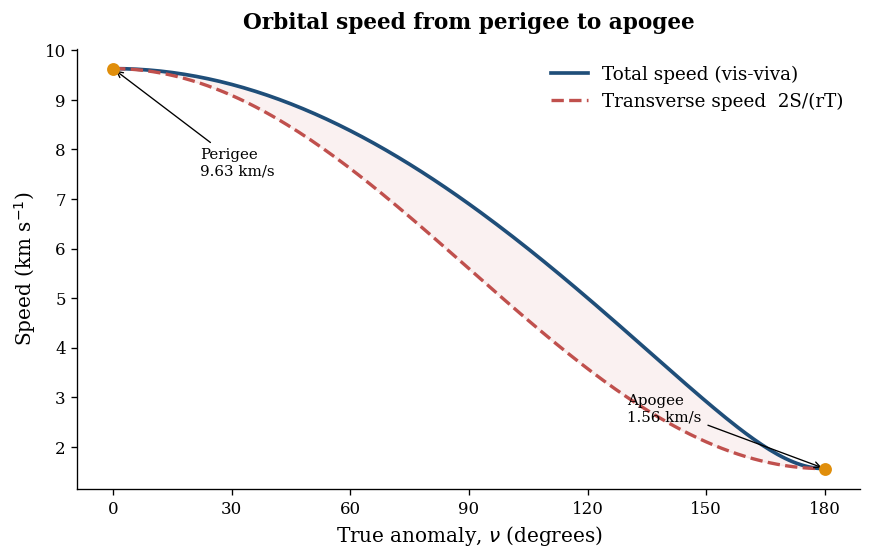

In [4]:
# ---------------------------------------------------------------
# Figure: orbital speed vs. true anomaly (both components)
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.4, 4.8))

ax.plot(nu_deg, v_tot,  color=C_TOTAL, lw=2.2, label="Total speed (vis-viva)")
ax.plot(nu_deg, v_perp, color=C_TRANS, lw=2.0, ls="--",
        label="Transverse speed  2S/(rT)")
ax.fill_between(nu_deg, v_perp, v_tot, color=C_TRANS, alpha=0.08)

# Apsides, where the two curves meet
for d, tag in ((0, "Perigee"), (180, "Apogee")):
    ax.scatter(d, v_tot[d], s=45, color=C_MARK, zorder=5)
    if d == 0:
        xytext, va = (d + 22, v_tot[d] - 1.6), "top"
    else:
        xytext, va = (d - 50, v_tot[d] + 0.9), "bottom"
    ax.annotate(f"{tag}\n{v_tot[d]:.2f} km/s",
                xy=(d, v_tot[d]), xytext=xytext, va=va,
                fontsize=9,
                arrowprops=dict(arrowstyle="->", lw=0.8))

ax.set_xlabel(r"True anomaly, $\nu$ (degrees)")
ax.set_ylabel(r"Speed (km s$^{-1}$)")
ax.set_title("Orbital speed from perigee to apogee", pad=12)
ax.set_xticks(range(0, 181, 30))
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


The shaded gap is the radial contribution to the speed: it is zero at both
apses and largest near the semi-latus rectum ($\nu = 90^\circ$), where the
total speed exceeds the transverse component by more than a kilometre per
second. Near apogee the satellite crawls at about 1.5 km/s, which is the
quantitative statement of the Molniya "dwell."


## 3. Time of flight via Kepler's equation

To know *when* the satellite reaches a given point, convert true anomaly $\nu$
to eccentric anomaly $E$, then to mean anomaly $M$, which is linear in time:

$$\tan\frac{E}{2} = \sqrt{\frac{1-e}{1+e}}\,\tan\frac{\nu}{2},
\qquad M = E - e\sin E,
\qquad t = \frac{M}{n},\ \ n = \frac{2\pi}{T}.$$

With $t=0$ fixed at perigee, this gives the travel time to any true anomaly.


In [5]:
# ---------------------------------------------------------------
# True anomaly -> eccentric anomaly -> mean anomaly -> time
# ---------------------------------------------------------------
def true_to_eccentric(nu, e):
    """Eccentric anomaly E [rad] from true anomaly nu [rad]."""
    return 2 * np.arctan(np.sqrt((1 - e) / (1 + e)) * np.tan(nu / 2))

def time_of_flight(nu, e, T):
    """Time [s] since perigee at true anomaly nu [rad] (t = 0 at perigee)."""
    E = true_to_eccentric(nu, e)
    M = E - e * np.sin(E)                 # Kepler's equation
    return M / (2 * np.pi / T)            # t = M / n

t_nu = time_of_flight(nu, E_ORB, T_ORB) / 3600.0     # hours

print(f"{'nu [deg]':>9s}{'E [rad]':>12s}{'t [h]':>10s}")
print("-" * 31)
for d in (0, 30, 60, 90, 120, 150, 180):
    E_d = true_to_eccentric(nu[d], E_ORB)
    print(f"{d:9d}{E_d:12.4f}{t_nu[d]:10.4f}")

print(f"\nCheck:  t(perigee) = {t_nu[0]:.3f} h,  "
      f"t(apogee) = {t_nu[-1]:.3f} h  (expected 0 and 6)")


 nu [deg]     E [rad]     t [h]
-------------------------------
        0      0.0000    0.0000
       30      0.2145    0.1161
       60      0.4559    0.2636
       90      0.7641    0.5053
      120      1.2160    1.0293
      150      1.9653    2.4804
      180      3.1416    6.0000

Check:  t(perigee) = 0.000 h,  t(apogee) = 6.000 h  (expected 0 and 6)


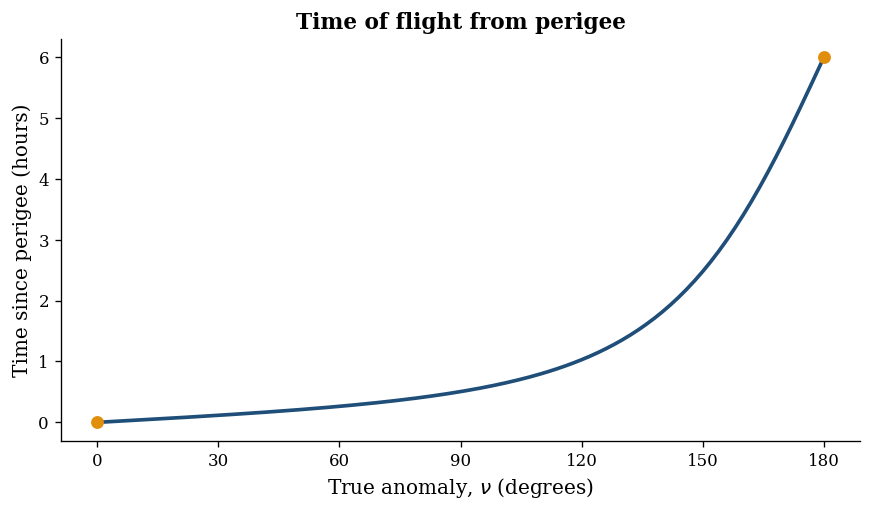

In [6]:
# ---------------------------------------------------------------
# Figure: travel time vs. true anomaly
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.4, 4.4))

ax.plot(nu_deg, t_nu, color=C_ORBIT, lw=2.2)
ax.scatter([0, 180], [t_nu[0], t_nu[-1]], s=45, color=C_MARK, zorder=5)

ax.set_xlabel(r"True anomaly, $\nu$ (degrees)")
ax.set_ylabel("Time since perigee (hours)")
ax.set_title("Time of flight from perigee")
ax.set_xticks(range(0, 181, 30))
fig.tight_layout()
plt.show()


The curve steepens toward apogee: the satellite spends far more of its
period near $\nu=180^\circ$ than near perigee. Roughly two-thirds of the
12-hour period is spent in the apogee half of the orbit, again the source of
the dwell.


## 4. Orbit visualization with hourly satellite positions

To place the satellite at each hour we solve the *forward* problem: given
$t$, the mean anomaly $M = nt$ is known, and Kepler's equation
$M = E - e\sin E$ is inverted for $E$ with Newton's method. The satellite
coordinates then come from the standard ellipse parametrization, with Earth
drawn to scale at the occupied focus.


In [7]:
# ---------------------------------------------------------------
# Invert Kepler's equation (Newton) and build hourly positions
# ---------------------------------------------------------------
def solve_kepler(M, e, tol=1e-12, itmax=100):
    """Eccentric anomaly E [rad] solving M = E - e sin E (Newton)."""
    M = np.atleast_1d(np.asarray(M, dtype=float))
    E = M.copy()                                  # good initial guess
    for _ in range(itmax):
        dE = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
        E -= dE
        if np.all(np.abs(dE) < tol):
            break
    return E

c_foc = a * E_ORB                                 # center-to-focus distance
n_mm  = 2 * np.pi / T_ORB                          # mean motion

hours   = np.arange(0, 13)                         # 0 ... 12 h
M_hours = n_mm * (hours * 3600.0)
E_hours = solve_kepler(M_hours, E_ORB)

# Ellipse centered at origin; perigee toward -x, Earth at the -x focus.
x_sat = -a * np.cos(E_hours)
y_sat =  b * np.sin(E_hours)
x_earth, y_earth = -c_foc, 0.0

# Full orbit path
E_path = np.linspace(0, 2 * np.pi, 1000)
x_path = -a * np.cos(E_path)
y_path =  b * np.sin(E_path)

# Sanity check: distance from Earth focus to perigee / apogee
r_chk = np.hypot(x_sat - x_earth, y_sat - y_earth)
print(f"r at t=0 h  : {r_chk[0]/1000:,.0f} km (perigee)")
print(f"r at t=6 h  : {r_chk[6]/1000:,.0f} km (apogee)")
print(f"r at t=12 h : {r_chk[12]/1000:,.0f} km (perigee)")


r at t=0 h  : 7,398 km (perigee)
r at t=6 h  : 45,823 km (apogee)
r at t=12 h : 7,398 km (perigee)


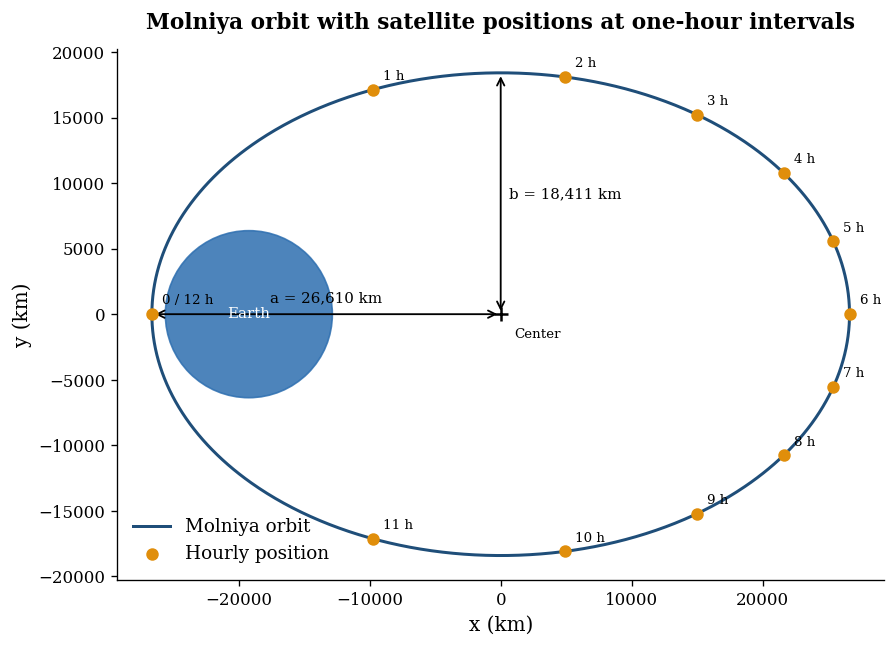

In [8]:
# ---------------------------------------------------------------
# Figure: the Molniya orbit with hourly markers
# ---------------------------------------------------------------
km = 1e3
fig, ax = plt.subplots(figsize=(7.6, 8.2))

# Orbit path
ax.plot(x_path/km, y_path/km, color=C_ORBIT, lw=1.8, label="Molniya orbit")

# Earth, drawn to scale at the focus
ax.add_patch(Circle((x_earth/km, y_earth/km), R_E/km,
                     color=C_EARTH, alpha=0.85, zorder=3))
ax.text(x_earth/km, y_earth/km, "Earth", color="white",
        ha="center", va="center", fontsize=9, zorder=4)

# Hourly positions (0 and 12 h coincide)
ax.scatter(x_sat[:12]/km, y_sat[:12]/km, s=42, color=C_MARK,
           zorder=5, label="Hourly position")
for h in range(12):
    lbl = "0 / 12 h" if h == 0 else f"{h} h"
    ax.annotate(lbl, (x_sat[h]/km, y_sat[h]/km),
                xytext=(6, 6), textcoords="offset points", fontsize=8)

# Center, semi-major and semi-minor axes
ax.scatter(0, 0, marker="+", s=80, color="black", zorder=6)
ax.annotate("Center", (0, 0), xytext=(8, -14),
            textcoords="offset points", fontsize=8)
ax.annotate("", xy=(-a/km, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="<->", lw=1.1))
ax.text(-a/2/km, 0.9e3, f"a = {a/km:,.0f} km", ha="center", fontsize=9)
ax.annotate("", xy=(0, b/km), xytext=(0, 0),
            arrowprops=dict(arrowstyle="<->", lw=1.1))
ax.text(0.6e3, b/2/km, f"b = {b/km:,.0f} km", va="center", fontsize=9)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Molniya orbit with satellite positions at one-hour intervals",
             pad=12)
ax.legend(frameon=False, loc="lower left")
fig.tight_layout()
plt.show()


The markers cluster near apogee and spread out near perigee, a direct
picture of the speed and time-of-flight results above: the satellite spends
hours drifting across the top of the orbit and only minutes whipping through
perigee. That is precisely the property a Molniya orbit is designed to exploit.


## 5. The Sun-Earth L1 point

The interior Lagrange point L1 sits on the Sun-Earth line where the two
gravitational pulls and the orbital (centrifugal) term balance in the rotating
frame. For a small mass ratio a compact first-order estimate is the Hill-radius
form

$$R \approx r\left(\frac{M_E}{3M_S}\right)^{1/3},$$

with $r = 1\,\text{AU}$. We report that estimate and then refine it by solving
the full collinear balance numerically.


In [9]:
# ---------------------------------------------------------------
# L1 distance from Earth: first-order estimate and numerical solve
# ---------------------------------------------------------------
r = AU

# First-order (Hill-radius) approximation
R_approx = r * (M_E / (3 * M_S))**(1/3)

# Numerical collinear balance in the rotating (barycentric) frame.
# x = distance from Sun toward Earth (0 < x < r); L1 near Earth.
omega2 = G * (M_S + M_E) / r**3          # mean-motion squared
x_bc   = r * M_E / (M_S + M_E)           # barycenter, measured from Sun

def net_force(x):
    return -G*M_S/x**2 + G*M_E/(r-x)**2 + omega2*(x - x_bc)

x_L1  = brentq(net_force, 0.90*r, 0.999999*r)
R_num = r - x_L1

print(f"First-order estimate   R = {R_approx/1000:,.0f} km "
      f"({R_approx/1e9:.4f} million km)")
print(f"Numerical solution     R = {R_num/1000:,.0f} km "
      f"({R_num/1e9:.4f} million km)")
print(f"Approximation error      = "
      f"{100*(R_approx - R_num)/R_num:+.2f} %")
print(f"\nFor scale, R / r        = {R_num/r:.4f}  "
      f"(about 1% of the Earth-Sun distance)")


First-order estimate   R = 1,496,433 km (1.4964 million km)
Numerical solution     R = 1,491,427 km (1.4914 million km)
Approximation error      = +0.34 %

For scale, R / r        = 0.0100  (about 1% of the Earth-Sun distance)


The first-order form lands within a few tenths of a percent of the true
1.49 million km, and the numerical solve recovers the value used operationally:
the SOHO and DSCOVR spacecraft orbit this point, roughly 1.5 million km
sunward of Earth, from where DSCOVR's EPIC imager returns full-disk views of
the sunlit Earth.


## Summary

| Quantity | Result |
|---|---|
| Semi-major axis $a$ | 26,610 km |
| Semi-minor axis $b$ | 18,411 km |
| Perigee / apogee altitude | ~1,030 km / ~39,450 km |
| Speed at perigee / apogee | 9.63 km/s / 1.55 km/s |
| Period spent past $\nu=90^\circ$ | ~2/3 of 12 h (apogee dwell) |
| Sun-Earth L1 distance | ~1.49 million km |

**What this demonstrates**

- Deriving full orbit geometry from two numbers ($e$, $T$) via Kepler's laws.
- Separating transverse and total speed cleanly, and showing where each applies.
- Inverting Kepler's equation numerically to animate position in time.
- Extending the same two-body machinery from Earth orbit to a Lagrange point.

**Reuse.** The functions (`semi_major_axis`, `radius_of_true_anomaly`,
`total_speed`, `time_of_flight`, `solve_kepler`, `net_force`) are written for
general $e$, $T$, and $\mu$, so the notebook doubles as a small toolkit for any
bound two-body orbit.

**References**

- Kepler's laws and the vis-viva equation: any standard orbital-mechanics text
  (e.g. Curtis, *Orbital Mechanics for Engineering Students*).
- Lagrange points and L1 missions: NASA SOHO and DSCOVR mission pages.
